<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/EMSC2010_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Title:

Dataset used:

- Original -->
  - Name:
  - Source:
- Cleaned -->
  - Name:
  - Source:

In [24]:
!pip install bambi #system command to install bambi package

In [38]:
# Import required packages for data handling, plotting, modelling, and model comparison

import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az
import pandas as pd

In [59]:
# Load the cleaned coral cover dataset from the Excel file
spreadsheet_name = 'weekly_dock_samples.xlsx'
df = pd.read_excel(spreadsheet_name)

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:84: UserWarning: File contains an invalid specification for 0. This will be removed
  warn(msg)


ValueError: Worksheet index 0 is invalid, 0 worksheets found

In [60]:
xls = pd.ExcelFile(spreadsheet_name)
print(xls.sheet_names)

[]


In [27]:
# Clean column names by removing extra spaces, making names uppercase, and replacing spaces with underscores

df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

# Display the first few rows to check that the dataset loaded correctly

df.head()

,DATETIME_UTC,DATETIME_LOCAL,LAT_N,LON_E,SITE_DESCRIPTION,TEMPERATURE,SALINITY
0,2012-06-06T18:44Z,2012-06-07T07:44,-2.818,-171.727,Kanton; Ocean,28.52,35.42
1,2012-06-06T18:44Z,2012-06-07T07:44,-2.818,-171.727,Kanton; Ocean,28.77,35.49
2,2012-06-06T19:05Z,2012-06-07T08:05,-2.813,-171.720,Kanton; Ocean,30.22,35.44
3,2012-06-06T19:15Z,2012-06-07T08:15,-2.812,-171.715,Kanton; Channel,27.97,35.45
4,2012-06-06T19:24Z,2012-06-07T08:24,-2.812,-171.715,Kanton; Channel,29.21,35.45


In [28]:
# Count how many observations are available for each site

df["SITE_DESCRIPTION"].value_counts()

,count
SITE_DESCRIPTION,
Kanton; Lagoon,77
Rawaki; Ocean,38
Enderbury; Ocean,32
Kanton; Ocean,32
Nikumaroro; Ocean,22
Kanton; Channel,19
Nikumororo; Nikumororo,10
Nikumaroro; Lagoon,8
Orona; Orona,6


In [29]:
# Define the columns used for modelling

site_col="SITE_DESCRIPTION"
x_col="DATETIME_LOCAL"
y_col="SALINITY"

In [30]:
# Select the desired ocean sites from the dataset for comparison

selected_site_descriptions = ['Kanton; Ocean', 'Rawaki; Ocean', 'Enderbury; Ocean']

site_types = [site for site in df[site_col].dropna().unique() if site in selected_site_descriptions]

# Filter the dataframe to only include the selected site types
df = df[df[site_col].isin(site_types)].copy()

site_1 = site_types[0]
site_2 = site_types[1]
site_3 = site_types[2]


# Print the site types used in the analysis
print("Site types used:" + str(site_types))

Site types used:['Kanton; Ocean', 'Enderbury; Ocean', 'Rawaki; Ocean']


In [31]:
# Filter the dataset so that only the two selected reef types are included

data = df[df[site_col].isin([site_1, site_2, site_3])]

# Keep only the variables needed for modelling and remove missing values
data = data[[site_col, x_col, y_col]].dropna()

/tmp/ipykernel_7456/896652071.py:22: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(2012,2012)


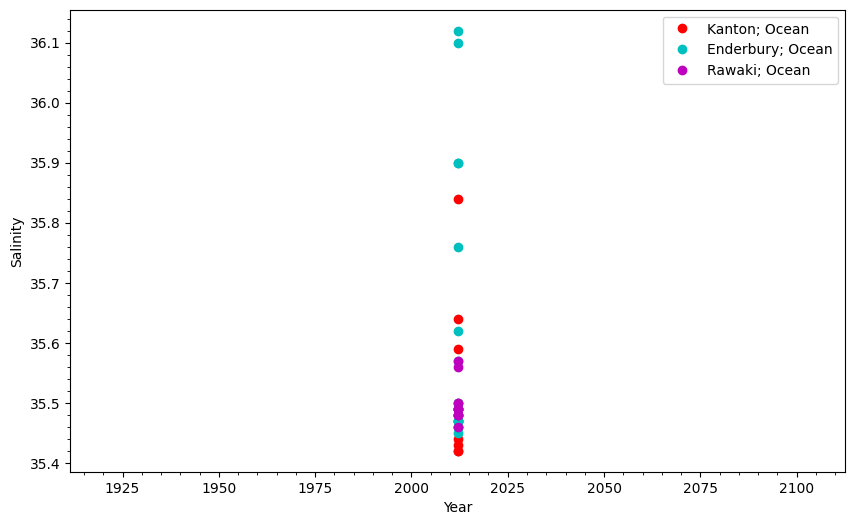

In [37]:
# Plot salinity score against year for the three selected sites
# This gives an initial visual check of the relationship before modelling

from matplotlib.ticker import MaxNLocator #to clean up the major ticks on x-axis and make them integers

# Convert DATETIME_LOCAL to datetime objects and extract the year
data['YEAR'] = pd.to_datetime(data[x_col]).dt.year

plt.figure(figsize=(10,6))

plt.plot(data[data[site_col] == site_1]['YEAR'], data[data[site_col] == site_1][y_col], 'o', color='r', label=site_1)
plt.plot(data[data[site_col] == site_2]['YEAR'], data[data[site_col] == site_2][y_col], 'o', color='c', label=site_2)
plt.plot(data[data[site_col] == site_3]['YEAR'], data[data[site_col] == site_3][y_col], 'o', color='m', label=site_3)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) #force integer ticks on x-axis

plt.xlabel("Year")
plt.ylabel("Salinity")

plt.legend()
plt.minorticks_on()

plt.show()